In [ ]:
'''
Measuring Political Bias in AI-Generated News Articles
Brandon Han, Madhusudan Rajesh, Jesse Mena — USC DSCI 531

Unified pipeline supporting multiple models:
  - GPT-2 (124M, full fine-tuning)
  - GPT-Neo-125M (125M, full fine-tuning)
  - GPT-Neo-1.3B (1.3B, full fine-tuning)
  - Mistral-7B (7B, 4-bit quantized + LoRA)

Toggle which models to run in Cell 3.
Run on Google Colab with A100 GPU.
'''

from google.colab import drive
import os

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive already mounted")

PROJECT_ROOT = '/content/drive/MyDrive/USC_DSCI531_Project'

os.makedirs("{0}/models".format(PROJECT_ROOT), exist_ok=True)
os.makedirs("{0}/generated_articles".format(PROJECT_ROOT), exist_ok=True)
os.makedirs("{0}/results/merged_pipeline".format(PROJECT_ROOT), exist_ok=True)
os.chdir(PROJECT_ROOT)

print("Working directory: {0}".format(os.getcwd()))

Mounted at /content/drive
Working directory: /content/drive/MyDrive/USC_DSCI531_Project


# CELL 2: IMPORTS

In [ ]:
!pip install -q peft bitsandbytes accelerate

os.environ["HF_HOME"] = "/content/hf_cache"
os.environ["TRANSFORMERS_CACHE"] = "/content/hf_cache"

import json
import random
import csv

from datetime import datetime
from collections import defaultdict

import numpy
import pandas

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    BitsAndBytesConfig,
    set_seed,
)
from datasets import Dataset as HFDataset

from peft import LoraConfig, get_peft_model, PeftModel, TaskType

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

import nltk
nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

print("PyTorch {0} | CUDA: {1}".format(torch.__version__, torch.cuda.is_available()))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: {0}".format(DEVICE))

if ( torch.cuda.is_available() ):
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print("GPU: {0} ({1:.0f} GB)".format(gpu_name, gpu_mem))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.4 MB/s eta 0:00:00
PyTorch 2.10.0+cu128 | CUDA: True
Device: cuda
GPU: NVIDIA A100-SXM4-40GB (42 GB)


# CELL 3: CONFIGURATION


In [ ]:
SEED = 42
set_seed(SEED)

# =====================================================================
# TOGGLE WHICH MODEL(S) TO RUN HERE
# =====================================================================
MODELS_TO_RUN = [
    "gpt2",
    "EleutherAI/gpt-neo-125M",
    "EleutherAI/gpt-neo-1.3B",
    "mistralai/Mistral-7B-v0.1",
]

#which models need LoRA instead of full fine-tuning
LORA_MODELS = {"mistralai/Mistral-7B-v0.1"}

#generation config — identical across all models and conditions
GEN_CONFIG = {
    "max_new_tokens": 512,
    "articles_per_prompt": 8,
    "temperature": 0.8,
    "top_p": 0.9,
    "top_k": 50,
    "min_words": 20,
}

#per-model fine-tuning config
FT_CONFIGS = {
    "gpt2": {
        "finetune_epochs": 3,
        "finetune_batch_size": 4,
        "gradient_accum_steps": 4,
        "finetune_lr": 5e-5,
        "max_seq_length": 512,
        "max_train_samples": None,     #use all articles
    },
    "EleutherAI/gpt-neo-125M": {
        "finetune_epochs": 3,
        "finetune_batch_size": 4,
        "gradient_accum_steps": 4,
        "finetune_lr": 5e-5,
        "max_seq_length": 512,
        "max_train_samples": None,
    },
    "EleutherAI/gpt-neo-1.3B": {
        "finetune_epochs": 2,
        "finetune_batch_size": 2,
        "gradient_accum_steps": 8,
        "finetune_lr": 2e-5,
        "max_seq_length": 512,
        "max_train_samples": 2000,
    },
    "mistralai/Mistral-7B-v0.1": {
        "finetune_epochs": 3,
        "finetune_batch_size": 2,
        "gradient_accum_steps": 8,
        "finetune_lr": 2e-4,
        "max_seq_length": 512,
        "max_train_samples": 3000,
    },
}


#LoRA config for large models
LORA_CONFIG = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
)


#4-bit quantization config
BNB_CONFIG = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

#paths
DATA_DIR       = "{0}/data/processed".format(PROJECT_ROOT)
MODEL_DIR      = "{0}/models".format(PROJECT_ROOT)
OUTPUT_DIR     = "{0}/results/merged_pipeline".format(PROJECT_ROOT)
CLASSIFIER_DIR = "{0}/models/bias_classifier_v3_deberta".format(PROJECT_ROOT)

#data files
DATA_FILES = {
    "left":   "{0}/qbias_left_clean.jsonl".format(DATA_DIR),
    "center": "{0}/qbias_center_clean.jsonl".format(DATA_DIR),
    "right":  "{0}/qbias_right_clean.jsonl".format(DATA_DIR),
}

#neutral prompts — consistent across all models and conditions
NEUTRAL_PROMPTS = {
    "immigration": [
        "Write a news article about immigration policy reform:",
        "Write a news article about the effects of immigration on local communities:",
    ],
    "healthcare": [
        "Write a news article about healthcare legislation:",
        "Write a news article about rising healthcare costs and their impact on American families:",
    ],
    "gun_control": [
        "Write a news article about gun control debate:",
        "Write a news article about recent developments in gun control legislation:",
    ],
    "climate": [
        "Write a news article about climate change policy:",
        "Write a news article about the economic impact of environmental regulations:",
    ],
    "abortion": [
        "Write a news article about abortion rights:",
    ],
    "voting_rights": [
        "Write a news article about voting rights legislation:",
    ],
    "policing": [
        "Write a news article about police reform:",
    ],
    "tax_policy": [
        "Write a news article about tax policy changes:",
    ],
    "education": [
        "Write a news article about education funding:",
    ],
    "supreme_court": [
        "Write a news article about Supreme Court nomination:",
    ],
}

#fine-tuning conditions
FINETUNE_LEANINGS = ["left", "center", "right"]

#custom colors
RED_DARK  = "#8B0000"
RED_MID   = "#B22222"
RED_LIGHT = "#E8967A"
GOLD_DARK = "#B8860B"
GOLD_MID  = "#DAA520"
GOLD_LIGHT= "#F0D58C"
GRAY_DARK = "#4A4A4A"
GRAY_MID  = "#8C8C8C"
GRAY_LIGHT= "#C0C0C0"
WHITE     = "#FFFFFF"

CONDITION_COLORS = {
    "baseline":         GRAY_MID,
    "finetune_left":    GOLD_MID,
    "finetune_center":  "#CD853F",
    "finetune_right":   RED_MID,
}

LABEL_COLORS = {"left": GOLD_MID, "center": GRAY_LIGHT, "right": RED_MID}

CONDITION_LABELS = {
    "baseline": "Baseline",
    "finetune_left": "Left-FT",
    "finetune_center": "Center-FT",
    "finetune_right": "Right-FT",
}

plt.rcParams.update({
    "figure.dpi": 200,
    "figure.facecolor": WHITE,
    "axes.facecolor": WHITE,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 9,
})


def short_name(model_name):
    '''Get short display name for a model.'''
    return model_name.split("/")[-1] if "/" in model_name else model_name


print("Configuration loaded")
print("  Models to run: {0}".format([short_name(m) for m in MODELS_TO_RUN]))
print("  Conditions:    baseline + {0}".format(FINETUNE_LEANINGS))
print("  Topics:        {0}".format(len(NEUTRAL_PROMPTS)))

Configuration loaded
  Models to run: ['gpt2', 'gpt-neo-125M', 'gpt-neo-1.3B', 'Mistral-7B-v0.1']
  Conditions:    baseline + ['left', 'center', 'right']
  Topics:        10


# CELL 4: LOAD DATA

In [ ]:
print("=" * 70)
print("LOADING QBIAS DATA")
print("=" * 70)

qbias_data = {}

for leaning in FINETUNE_LEANINGS:

    path = DATA_FILES.get(leaning, "")

    if ( not os.path.exists(path) ):
        print("  WARNING: {0} not found at {1}".format(leaning, path))
        continue

    df = pandas.read_json(path, lines=True)

    text_col = None

    for candidate in ["article_text_clean", "article_text", "text", "content"]:
        if ( candidate in df.columns ):
            text_col = candidate
            break

    if ( text_col is None ):
        print("  WARNING: no text column for {0}".format(leaning))
        continue

    df = df[df[text_col].astype(str).str.len() > 100].reset_index(drop=True)
    df["text"] = df[text_col]

    qbias_data[leaning] = df
    print("  {0:<8} {1:>6} articles".format(leaning, len(df)))

print("\n  Total: {0} articles".format(sum(len(d) for d in qbias_data.values())))

LOADING QBIAS DATA
  left       6356 articles
  center     2986 articles
  right      4653 articles

  Total: 13995 articles


# CELL 5: LOAD CLASSIFIER

In [ ]:
print("=" * 70)
print("LOADING BIAS CLASSIFIER")
print("=" * 70)

clf_meta_path = "{0}/training_metadata.json".format(CLASSIFIER_DIR)

with open(clf_meta_path, "r") as f:
    clf_meta = json.load(f)

CLF_IDX_TO_LABEL = {int(k): v for k, v in clf_meta["idx_to_label"].items()}
CLF_MAX_LENGTH   = clf_meta["max_length"]

clf_tokenizer = AutoTokenizer.from_pretrained(CLASSIFIER_DIR)
clf_model = AutoModelForSequenceClassification.from_pretrained(CLASSIFIER_DIR).to(DEVICE)
clf_model.eval()

print("  Model:    {0}".format(clf_meta["model_name"]))
print("  Accuracy: {0:.3f}".format(clf_meta["test_accuracy"]))
print("  Macro F1: {0:.3f}".format(clf_meta["test_macro_f1"]))


def score_articles(texts, batch_size=16):
    '''
    Score article texts for political bias.
    '''

    results = []

    for i in range(0, len(texts), batch_size):

        batch = [str(t) for t in texts[i:i + batch_size]]

        inputs = clf_tokenizer(
            batch, max_length=CLF_MAX_LENGTH, padding=True,
            truncation=True, return_tensors="pt",
        ).to(DEVICE)

        with torch.no_grad():
            logits = clf_model(**inputs).logits
            probs = torch.softmax(logits.float(), dim=-1).cpu().numpy()

        for p in probs:
            pred_idx = int(p.argmax())
            safe_p = numpy.clip(p, 1e-12, 1.0)
            results.append({
                "p_left": float(p[0]),
                "p_center": float(p[1]),
                "p_right": float(p[2]),
                "pred_label": CLF_IDX_TO_LABEL[pred_idx],
                "ideology_score": float(p[2] - p[0]),
                "confidence": float(numpy.max(p)),
                "entropy": float(-(safe_p * numpy.log(safe_p)).sum()),
            })

    return pandas.DataFrame(results)


print("  Classifier loaded")

LOADING BIAS CLASSIFIER


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Model:    roberta-base
  Accuracy: 0.610
  Macro F1: 0.599
  Classifier loaded


# CELL 6: GENERATION & FINE-TUNING FUNCTIONS

In [ ]:
print("=" * 70)
print("DEFINING GENERATION & FINE-TUNING FUNCTIONS")
print("=" * 70)


def generate_articles(prompt, model, tokenizer):
    '''
    Generate articles from `prompt', strip prefix, filter short outputs.
    '''

    inputs = tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=128
    ).to(model.device)

    prompt_length = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=GEN_CONFIG["max_new_tokens"],
            num_return_sequences=GEN_CONFIG["articles_per_prompt"],
            temperature=GEN_CONFIG["temperature"],
            top_p=GEN_CONFIG["top_p"],
            top_k=GEN_CONFIG["top_k"],
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            no_repeat_ngram_size=3,
        )

    articles = []

    for output_ids in outputs:
        generated_ids = output_ids[prompt_length:]
        text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

        if ( len(text.split()) >= GEN_CONFIG["min_words"] ):
            articles.append(text)

    return articles


def generate_all_topics(model, tokenizer, condition_label, model_name):
    '''
    Generate articles for all prompts. Returns list of result dicts.
    '''

    all_results = []
    counter = 0
    topic_list = sorted(NEUTRAL_PROMPTS.keys())

    for topic_idx in range(len(topic_list)):

        topic = topic_list[topic_idx]
        prompt_list = NEUTRAL_PROMPTS[topic]

        print("    [{0}/{1}] {2}".format(topic_idx + 1, len(topic_list), topic))

        for prompt in prompt_list:

            articles = generate_articles(prompt, model, tokenizer)

            for article_text in articles:
                all_results.append({
                    "condition": condition_label,
                    "topic": topic,
                    "prompt": prompt,
                    "article_text": article_text,
                    "model": model_name,
                    "timestamp": datetime.now().isoformat(),
                })
                counter += 1

        print("      {0} articles so far".format(counter))

    return all_results


def prepare_finetune_dataset(leaning, model_name, ft_config):
    '''
    Prepare tokenized dataset for fine-tuning.
    '''

    subset = qbias_data[leaning].copy()

    max_samples = ft_config["max_train_samples"]

    if ( max_samples is not None and len(subset) > max_samples ):
        subset = subset.sample(max_samples, random_state=SEED)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    if ( tokenizer.pad_token is None ):
        tokenizer.pad_token = tokenizer.eos_token

    def tokenize_fn(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            max_length=ft_config["max_seq_length"],
            padding="max_length",
        )

    hf_ds = HFDataset.from_pandas(subset[["text"]].reset_index(drop=True))
    hf_ds = hf_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
    hf_ds = hf_ds.add_column("labels", hf_ds["input_ids"])

    print("    Dataset [{0}]: {1} articles".format(leaning, len(hf_ds)))

    return hf_ds


def finetune_standard(leaning, model_name, ft_config):
    '''
    Full fine-tuning using HuggingFace Trainer.
    Trains in memory — does NOT save to Drive.
    Returns tuple([model, tokenizer]).
    '''

    print("    Loading {0} for fine-tuning...".format(short_name(model_name)))

    model = AutoModelForCausalLM.from_pretrained(model_name)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    if ( tokenizer.pad_token is None ):
        tokenizer.pad_token = tokenizer.eos_token
        model.config.pad_token_id = model.config.eos_token_id

    #prepare dataset
    ft_dataset = prepare_finetune_dataset(leaning, model_name, ft_config)

    #use a temp output dir that won't persist
    temp_dir = "/content/temp_trainer_{0}_{1}".format(short_name(model_name), leaning)

    training_args = TrainingArguments(
        output_dir=temp_dir,
        num_train_epochs=ft_config["finetune_epochs"],
        per_device_train_batch_size=ft_config["finetune_batch_size"],
        gradient_accumulation_steps=ft_config["gradient_accum_steps"],
        learning_rate=ft_config["finetune_lr"],
        weight_decay=0.01,
        warmup_ratio=0.1,
        fp16=(DEVICE.type == "cuda"),
        save_strategy="no",
        logging_steps=50,
        report_to="none",
        dataloader_pin_memory=False,
        seed=SEED,
    )

    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

    trainer = Trainer(
        model=model, args=training_args,
        train_dataset=ft_dataset, data_collator=data_collator,
    )

    print("    Fine-tuning {0} on [{1}]...".format(short_name(model_name), leaning))
    trainer.train()

    #clean up temp dir
    import shutil
    if ( os.path.exists(temp_dir) ):
        shutil.rmtree(temp_dir)

    print("    Fine-tuning complete (model kept in session memory)")

    model.eval()

    return tuple([model, tokenizer])


def finetune_lora(leaning, model_name, ft_config):
    '''
    Fine-tune using 4-bit quantization + LoRA.
    Trains in memory — does NOT save to Drive.
    Returns tuple([model, tokenizer]).
    '''

    print("    Loading {0} in 4-bit for LoRA...".format(short_name(model_name)))

    model = AutoModelForCausalLM.from_pretrained(
        model_name, quantization_config=BNB_CONFIG, device_map="auto",
    )

    model.gradient_checkpointing_enable()
    model = get_peft_model(model, LORA_CONFIG)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print("    Trainable: {0:,} / {1:,} ({2:.2f}%)".format(trainable, total, 100 * trainable / total))

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    if ( tokenizer.pad_token is None ):
        tokenizer.pad_token = tokenizer.eos_token
        model.config.pad_token_id = model.config.eos_token_id

    #prepare dataset
    ft_dataset = prepare_finetune_dataset(leaning, model_name, ft_config)

    temp_dir = "/content/temp_trainer_{0}_{1}_lora".format(short_name(model_name), leaning)

    training_args = TrainingArguments(
        output_dir=temp_dir,
        num_train_epochs=ft_config["finetune_epochs"],
        per_device_train_batch_size=ft_config["finetune_batch_size"],
        gradient_accumulation_steps=ft_config["gradient_accum_steps"],
        learning_rate=ft_config["finetune_lr"],
        weight_decay=0.01,
        warmup_ratio=0.1,
        fp16=False, bf16=False,
        save_strategy="no",
        logging_steps=50,
        report_to="none",
        dataloader_pin_memory=False,
        seed=SEED,
        gradient_checkpointing=True,
        optim="paged_adamw_8bit",
    )

    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

    trainer = Trainer(
        model=model, args=training_args,
        train_dataset=ft_dataset, data_collator=data_collator,
    )

    print("    Fine-tuning with LoRA on [{0}]...".format(leaning))
    trainer.train()

    #clean up temp dir
    import shutil
    if ( os.path.exists(temp_dir) ):
        shutil.rmtree(temp_dir)

    print("    LoRA fine-tuning complete (model kept in memory)")

    model.eval()

    return tuple([model, tokenizer])


def load_model_for_generation(model_name):
    '''
    Load a pretrained model for baseline generation.
    Returns tuple([model, tokenizer]).
    '''

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if DEVICE.type == "cuda" else torch.float32,
    ).to(DEVICE)

    model.eval()

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    if ( tokenizer.pad_token is None ):
        tokenizer.pad_token = tokenizer.eos_token

    model.config.pad_token_id = tokenizer.eos_token_id

    return tuple([model, tokenizer])


print("  All functions defined")

DEFINING GENERATION & FINE-TUNING FUNCTIONS
  All functions defined


# CELL 7: RUN ALL MODELS — BASELINE + FINE-TUNE + GENERATE

In [ ]:
print("=" * 70)
print("RUNNING MODEL(S) PIPELINE(S)")
print("=" * 70)

all_results = []

for model_name in MODELS_TO_RUN:

    is_lora = model_name in LORA_MODELS
    ft_config = FT_CONFIGS[model_name]
    sname = short_name(model_name)

    print("\n" + "=" * 60)
    print("MODEL: {0} {1}".format(model_name, "(LoRA)" if is_lora else "(full FT)"))
    print("=" * 60)

    #--- Baseline ---
    print("\n  Phase 1: Baseline generation...")

    model, tokenizer = load_model_for_generation(model_name)

    print("    Loaded ({0:.1f}M params)".format(
        sum(p.numel() for p in model.parameters()) / 1e6))

    baseline_results = generate_all_topics(model, tokenizer, "baseline", model_name)
    all_results.extend(baseline_results)
    print("    Baseline: {0} articles".format(len(baseline_results)))

    del model
    if ( DEVICE.type == "cuda" ):
        torch.cuda.empty_cache()

    #--- Fine-tune & generate for each leaning ---
    print("\n  Phase 2: Fine-tune & generate...")

    for leaning in FINETUNE_LEANINGS:

        if ( leaning not in qbias_data ):
            print("    Skipping {0} — no data".format(leaning))
            continue

        condition = "finetune_{0}".format(leaning)
        print("\n    Condition: {0}".format(condition))

        #fine-tune and get model back in memory
        if ( is_lora ):
            ft_model, ft_tokenizer = finetune_lora(leaning, model_name, ft_config)
        else:
            ft_model, ft_tokenizer = finetune_standard(leaning, model_name, ft_config)

        #generate directly from the in-memory model
        ft_results = generate_all_topics(ft_model, ft_tokenizer, condition, model_name)
        all_results.extend(ft_results)
        print("    {0}: {1} articles".format(condition, len(ft_results)))

        #free memory before next condition
        del ft_model
        if ( DEVICE.type == "cuda" ):
            torch.cuda.empty_cache()

    print("\n  {0} complete".format(sname))

df_all = pandas.DataFrame(all_results)

print("\n" + "=" * 60)
print("ALL GENERATION COMPLETE")
print("  Total articles: {0}".format(len(df_all)))
print("  By model:")

for model_name in MODELS_TO_RUN:
    count = len(df_all[df_all["model"] == model_name])
    print("    {0:<25} {1}".format(short_name(model_name), count))

RUNNING MODEL(S) PIPELINE(S)

MODEL: gpt2 (full FT)

  Phase 1: Baseline generation...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

...

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


    Dataset [right]: 3000 articles
    Fine-tuning with LoRA on [right]...


Step,Training Loss
50,1.779044
100,1.742431
150,1.759178
200,1.622281
250,1.171476
300,1.139996
350,1.137109
400,0.857364
450,0.512472
500,0.502024


    LoRA fine-tuning complete (model kept in memory)
    [1/10] abortion
      8 articles so far
    [2/10] climate
      24 articles so far
    [3/10] education
      32 articles so far
    [4/10] gun_control
      48 articles so far
    [5/10] healthcare
      64 articles so far
    [6/10] immigration
      80 articles so far
    [7/10] policing
      88 articles so far
    [8/10] supreme_court
      96 articles so far
    [9/10] tax_policy
      104 articles so far
    [10/10] voting_rights
      112 articles so far
    finetune_right: 112 articles

  Mistral-7B-v0.1 complete

ALL GENERATION COMPLETE
  Total articles: 1751
  By model:
    gpt2                      417
    gpt-neo-125M              441
    gpt-neo-1.3B              445
    Mistral-7B-v0.1           448


# CELL 8: SCORE ALL ARTICLES

In [ ]:
print("=" * 70)
print("SCORING ALL GENERATED ARTICLES")
print("=" * 70)

scores_df = score_articles(df_all["article_text"].tolist())

for col in scores_df.columns:
    df_all[col] = scores_df[col].values

#sentiment
vader = SentimentIntensityAnalyzer()
print("  Computing VADER sentiment...")

df_all["sentiment"] = [
    vader.polarity_scores(str(t))["compound"]
    for t in df_all["article_text"]
]

scored_path = "{0}/all_articles_scored.csv".format(OUTPUT_DIR)
df_all.to_csv(scored_path, index=False)
print("  Saved to {0}".format(scored_path))

SCORING ALL GENERATED ARTICLES
  Computing VADER sentiment...
  Saved to /content/drive/MyDrive/USC_DSCI531_Project/results/merged_pipeline/all_articles_scored.csv


# CELL 9: STATISTICAL ANALYSIS

In [ ]:
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

conditions_list = ["baseline", "finetune_left", "finetune_center", "finetune_right"]

for model_name in MODELS_TO_RUN:

    sname = short_name(model_name)
    model_df = df_all[df_all["model"] == model_name]

    print("\n" + "-" * 60)
    print("MODEL: {0}".format(sname))
    print("-" * 60)

    #means
    print("\n  {0:<20} {1:>8} {2:>8} {3:>8} {4:>5}".format(
        "Condition", "Mean", "Median", "Std", "N"))

    for condition in conditions_list:

        subset = model_df[model_df["condition"] == condition]["ideology_score"]

        if ( len(subset) == 0 ):
            continue

        print("  {0:<20} {1:>+8.4f} {2:>+8.4f} {3:>8.4f} {4:>5}".format(
            CONDITION_LABELS.get(condition, condition),
            subset.mean(), subset.median(), subset.std(), len(subset)))

    #pairwise vs baseline
    base = model_df[model_df["condition"] == "baseline"]["ideology_score"]

    if ( len(base) == 0 ):
        continue

    print("\n  Pairwise vs Baseline:")

    for condition in conditions_list:

        if ( condition == "baseline" ):
            continue

        other = model_df[model_df["condition"] == condition]["ideology_score"]

        if ( len(other) == 0 ):
            continue

        ks_stat, ks_p = stats.ks_2samp(base, other)
        t_stat, t_p = stats.ttest_ind(base, other)
        shift = other.mean() - base.mean()

        print("    vs {0:<12} shift={1:>+7.4f}  KS p={2:.4f}{3}  t p={4:.4f}{5}".format(
            CONDITION_LABELS.get(condition, condition),
            shift, ks_p, "*" if ks_p < 0.05 else " ",
            t_p, "*" if t_p < 0.05 else " "))

#cross-model right-FT shift comparison
if ( len(MODELS_TO_RUN) > 1 ):

    print("\n" + "=" * 60)
    print("CROSS-MODEL: Right-FT Shift Comparison")
    print("=" * 60)
    print("  {0:<25} {1:>10} {2:>10} {3:>8} {4:>8}".format(
        "Model", "Base", "Right-FT", "Shift", "p-value"))

    for model_name in MODELS_TO_RUN:

        model_df = df_all[df_all["model"] == model_name]

        base = model_df[model_df["condition"] == "baseline"]["ideology_score"]
        right = model_df[model_df["condition"] == "finetune_right"]["ideology_score"]

        if ( len(base) == 0 or len(right) == 0 ):
            continue

        t_stat, t_p = stats.ttest_ind(base, right)
        shift = right.mean() - base.mean()

        print("  {0:<25} {1:>+10.4f} {2:>+10.4f} {3:>+8.4f} {4:>8.4f} {5}".format(
            short_name(model_name), base.mean(), right.mean(), shift, t_p,
            "*" if t_p < 0.05 else ""))

STATISTICAL ANALYSIS

------------------------------------------------------------
MODEL: gpt2
------------------------------------------------------------

  Condition                Mean   Median      Std     N
  Baseline              +0.1704  +0.1306   0.5636    81
  Left-FT               +0.2596  +0.3744   0.4986   112
  Center-FT             +0.2537  +0.0155   0.3573   112
  Right-FT              +0.6446  +0.7825   0.3585   112

  Pairwise vs Baseline:
    vs Left-FT      shift=+0.0893  KS p=0.1483   t p=0.2468 
    vs Center-FT    shift=+0.0833  KS p=0.0000*  t p=0.2110 
    vs Right-FT     shift=+0.4742  KS p=0.0000*  t p=0.0000*

------------------------------------------------------------
MODEL: gpt-neo-125M
------------------------------------------------------------

  Condition                Mean   Median      Std     N
  Baseline              +0.2650  +0.1505   0.2957   111
  Left-FT               +0.2143  +0.0625   0.4375   112
  Center-FT             +0.0798  -0.0002   

# CELL 10: FIGURES — PER-MODEL FOUR-PANEL

GENERATING FIGURES


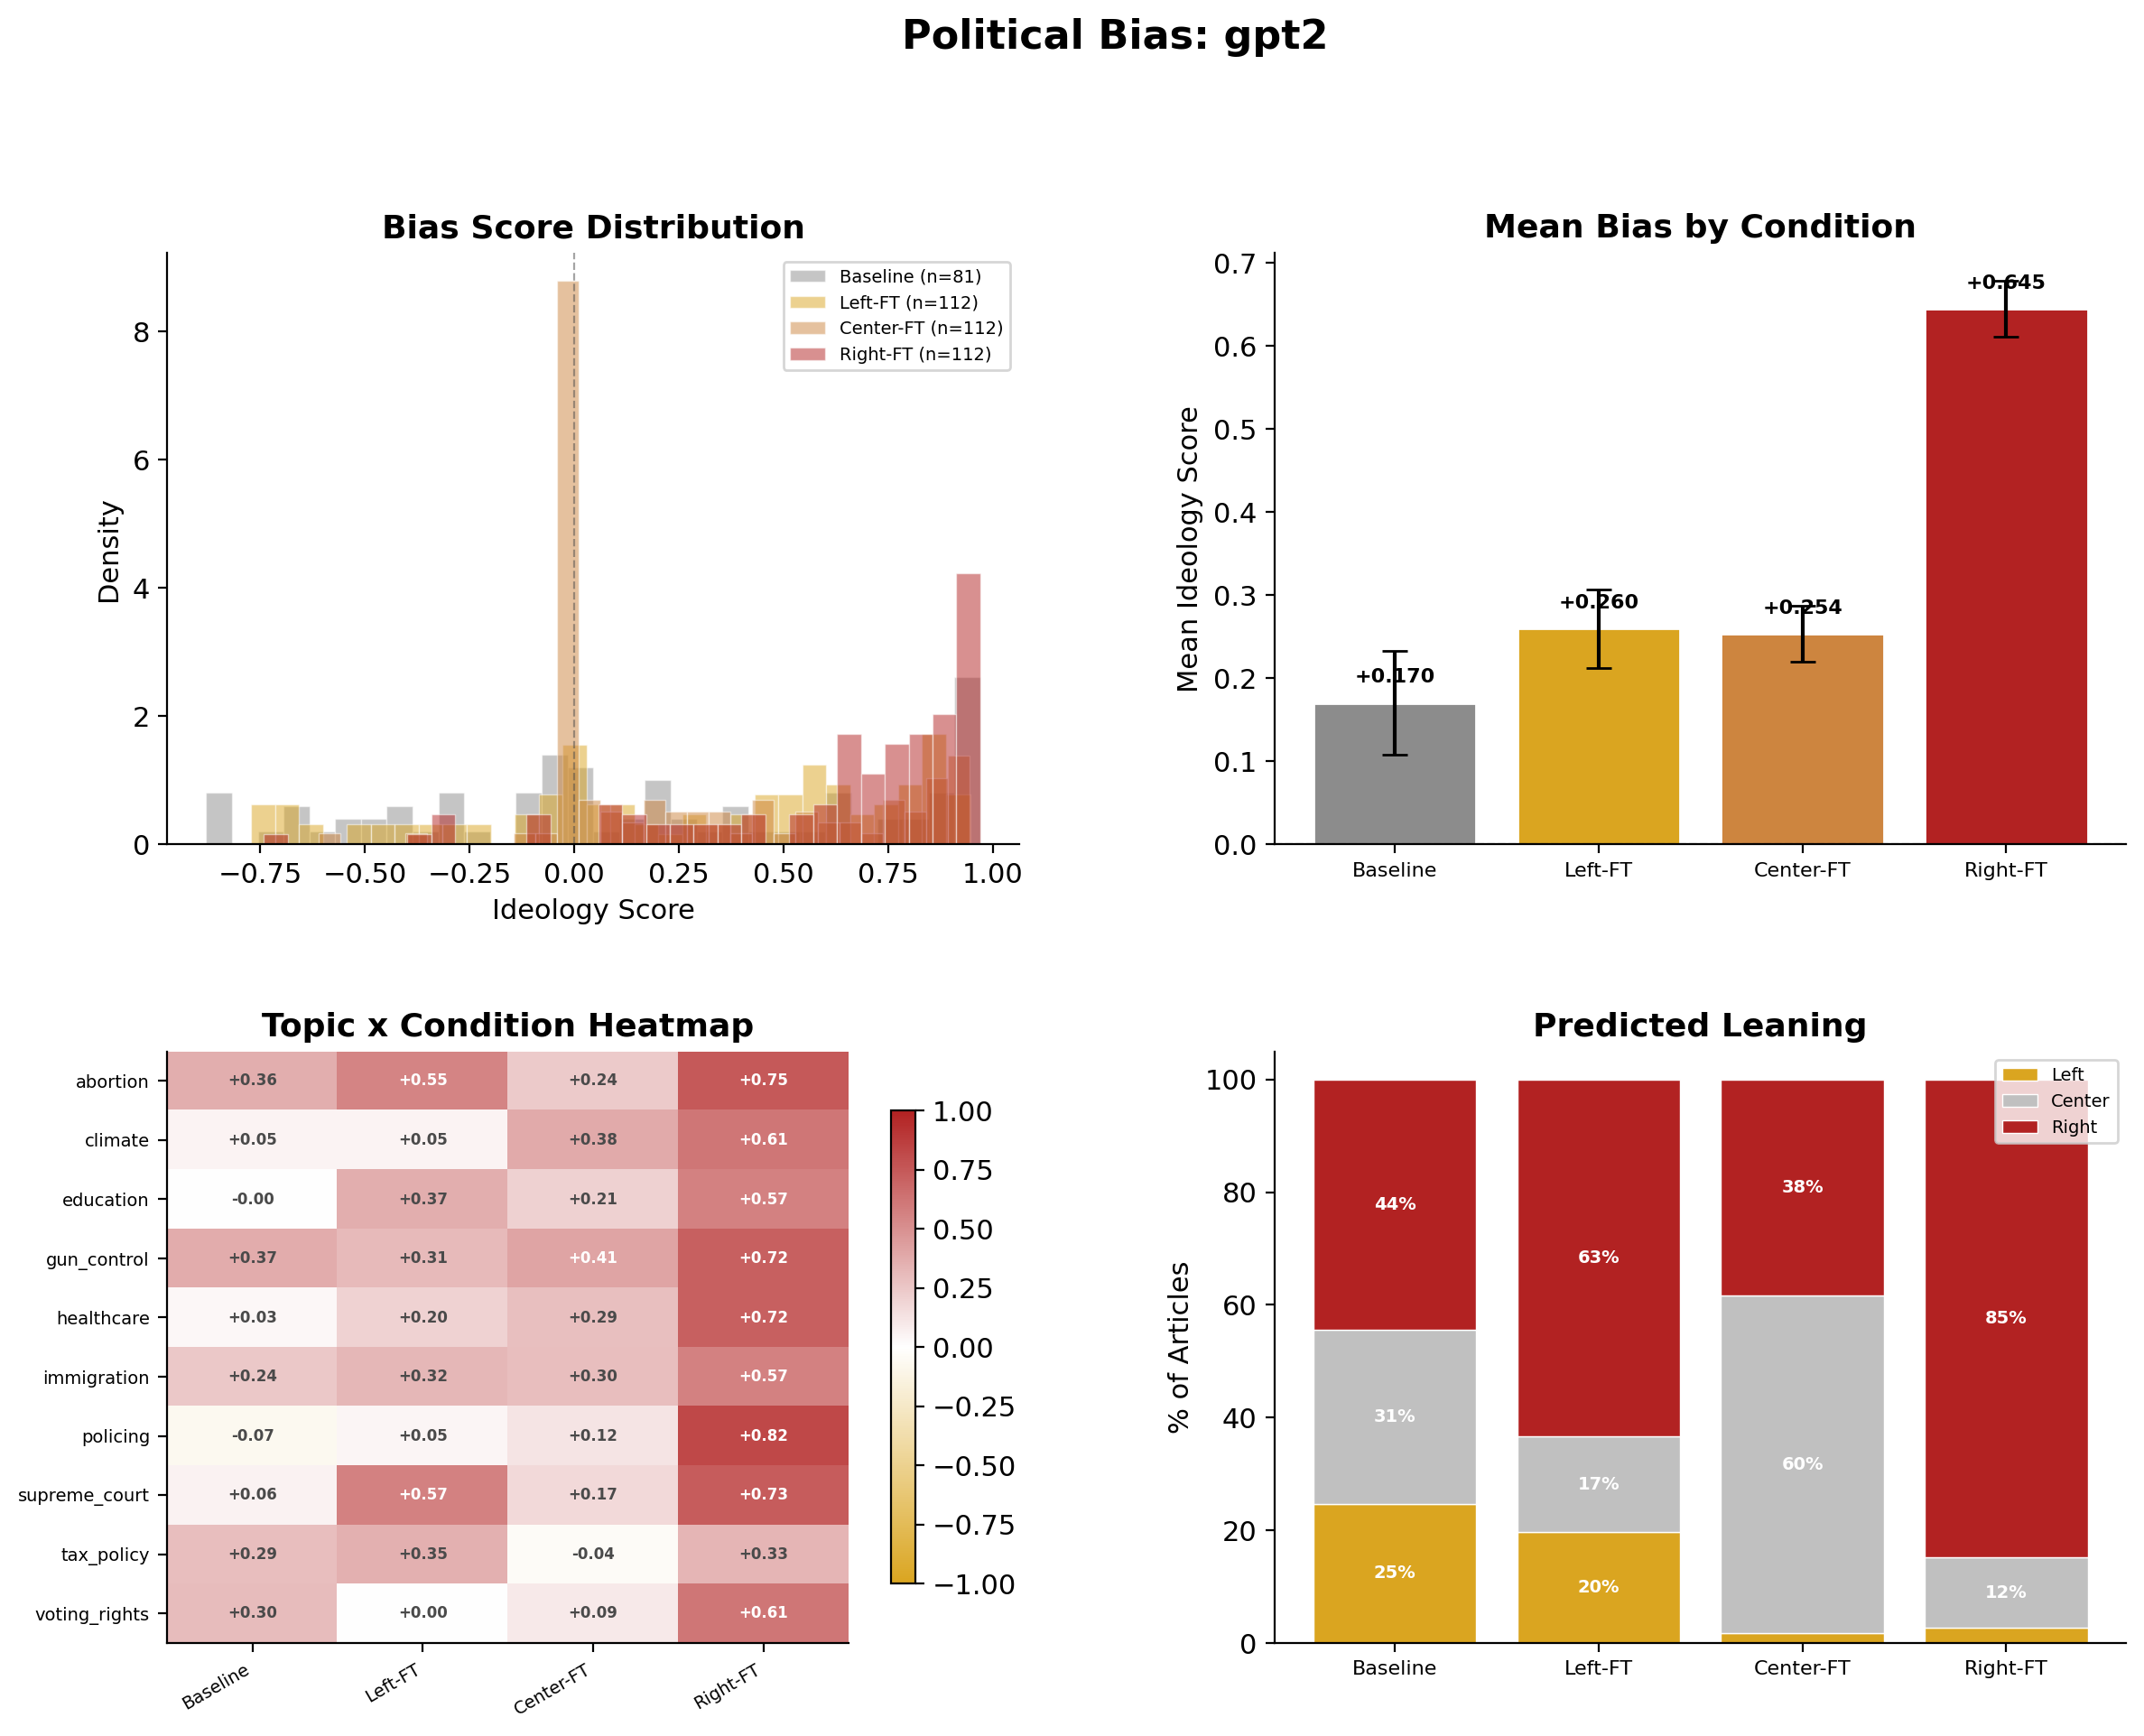

  Saved fig_gpt2_overview.png


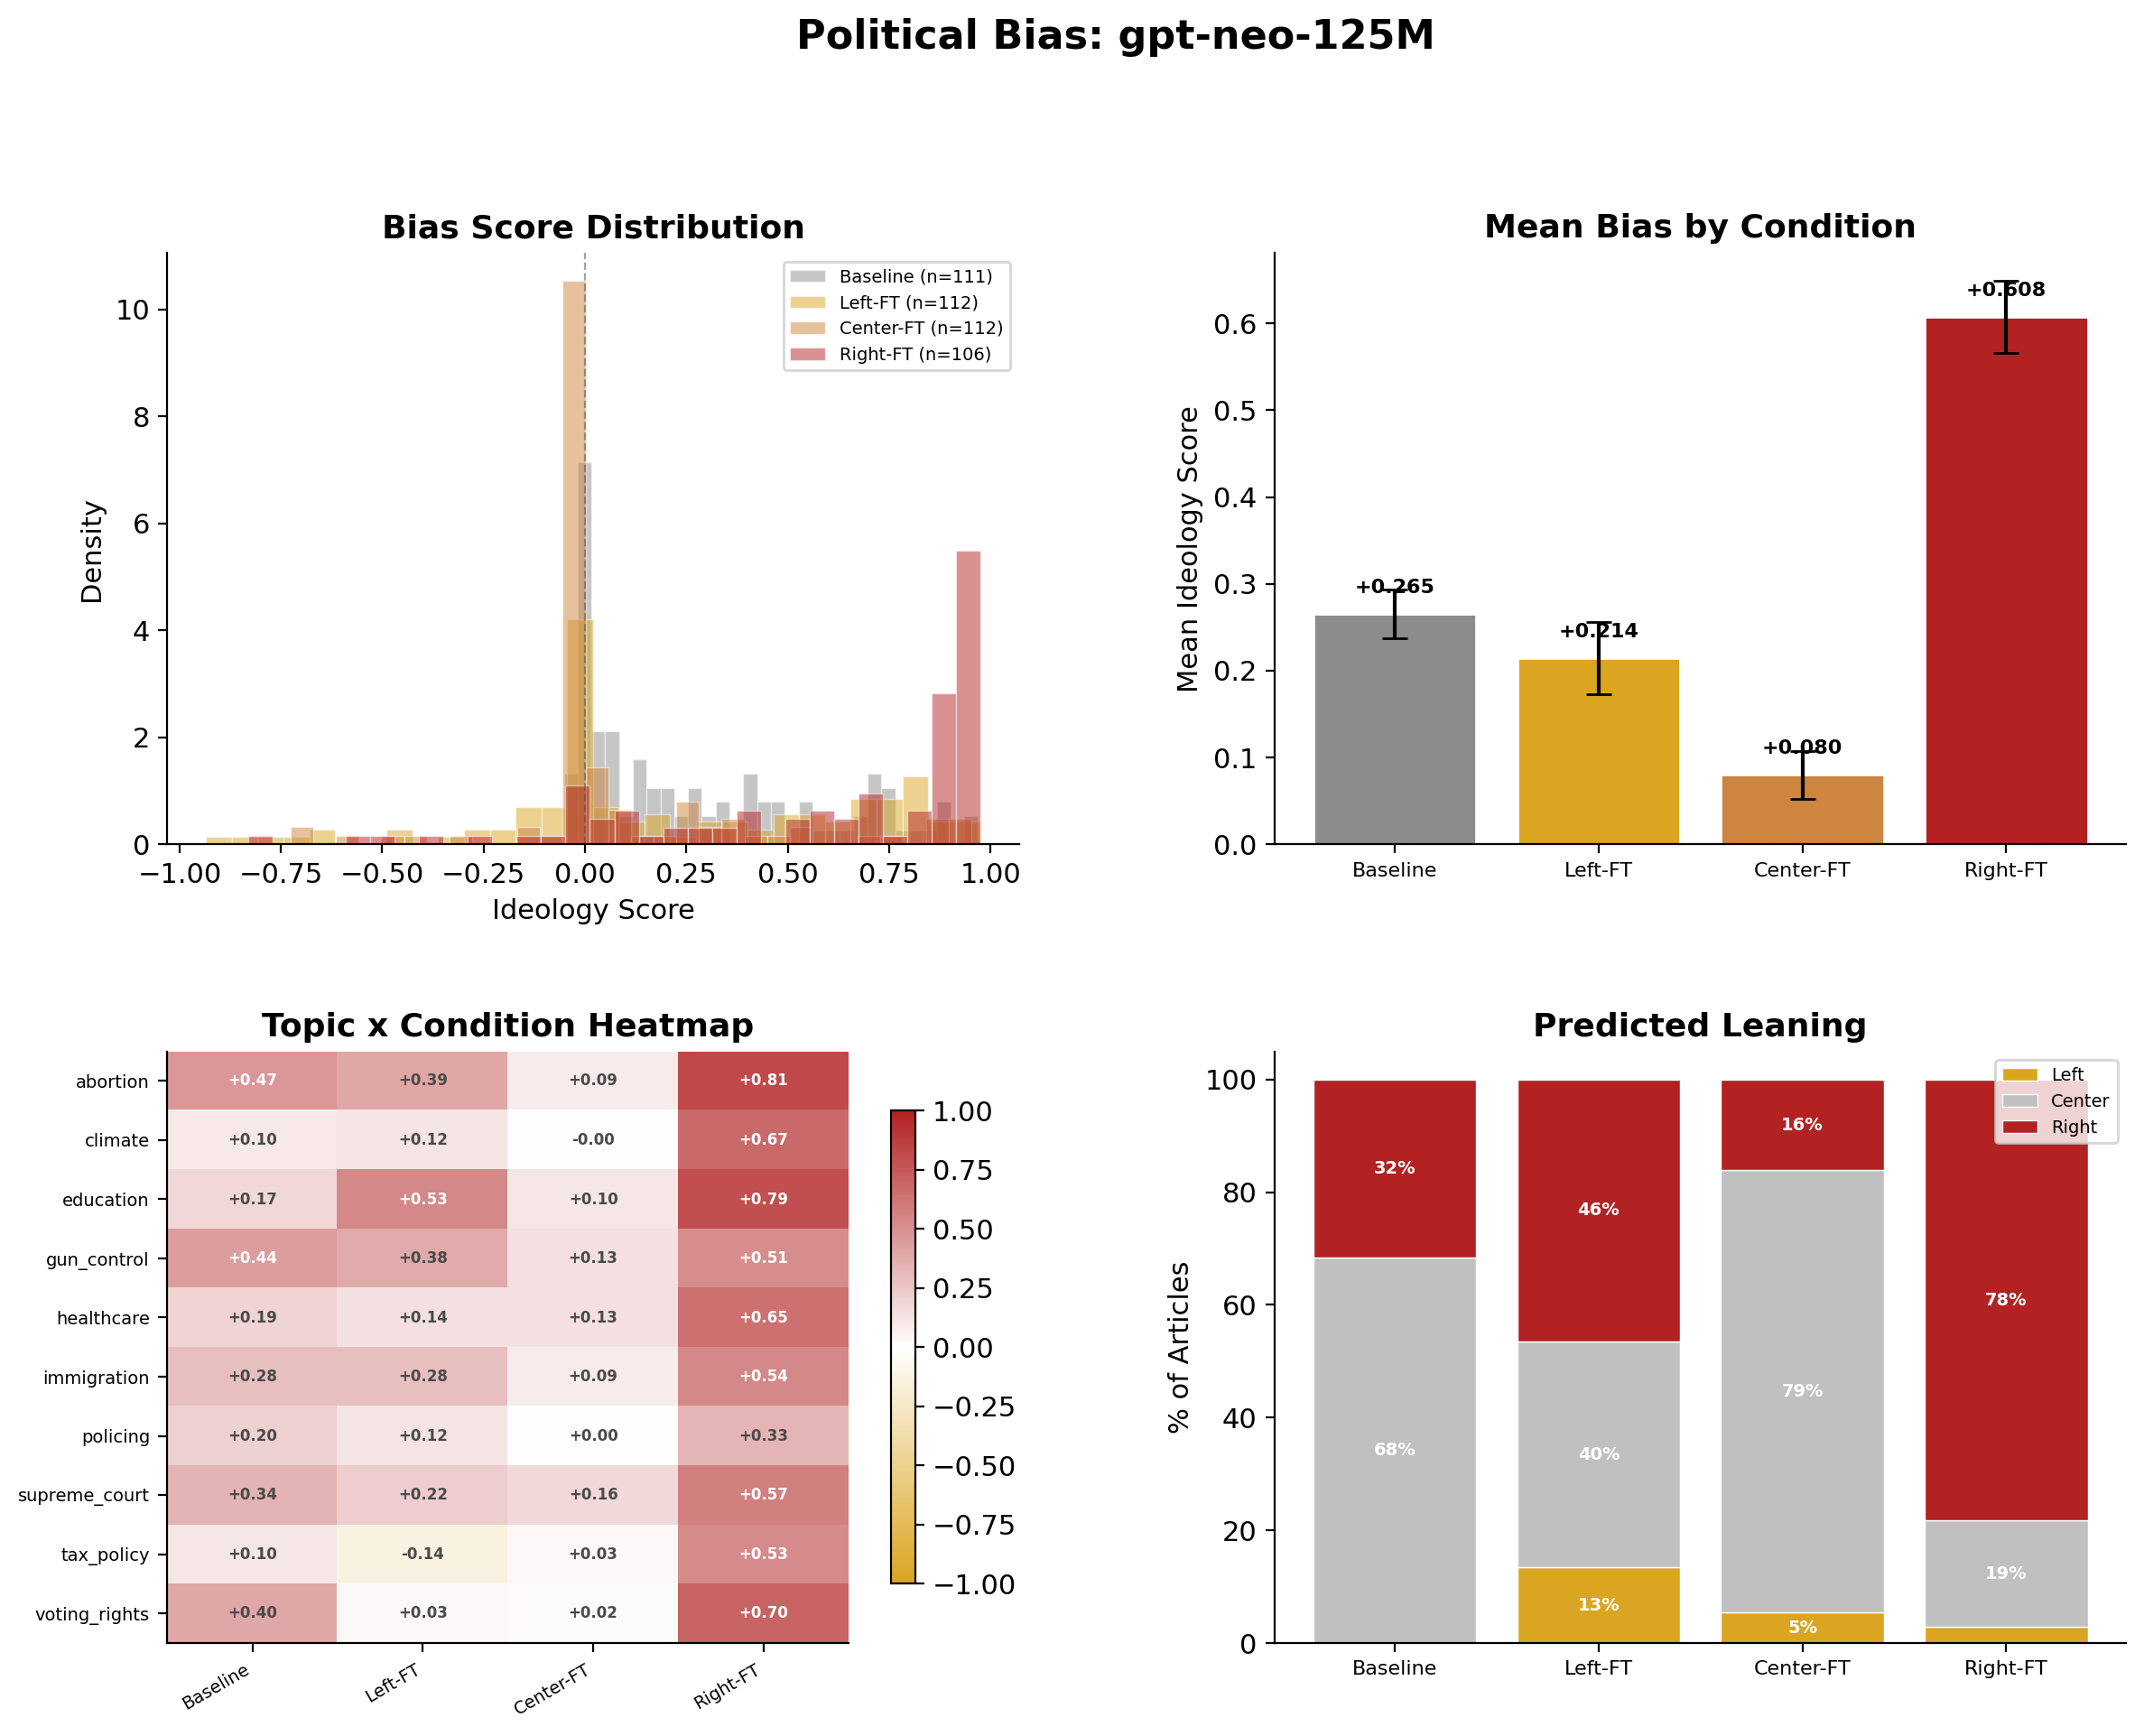

  Saved fig_gpt-neo-125M_overview.png


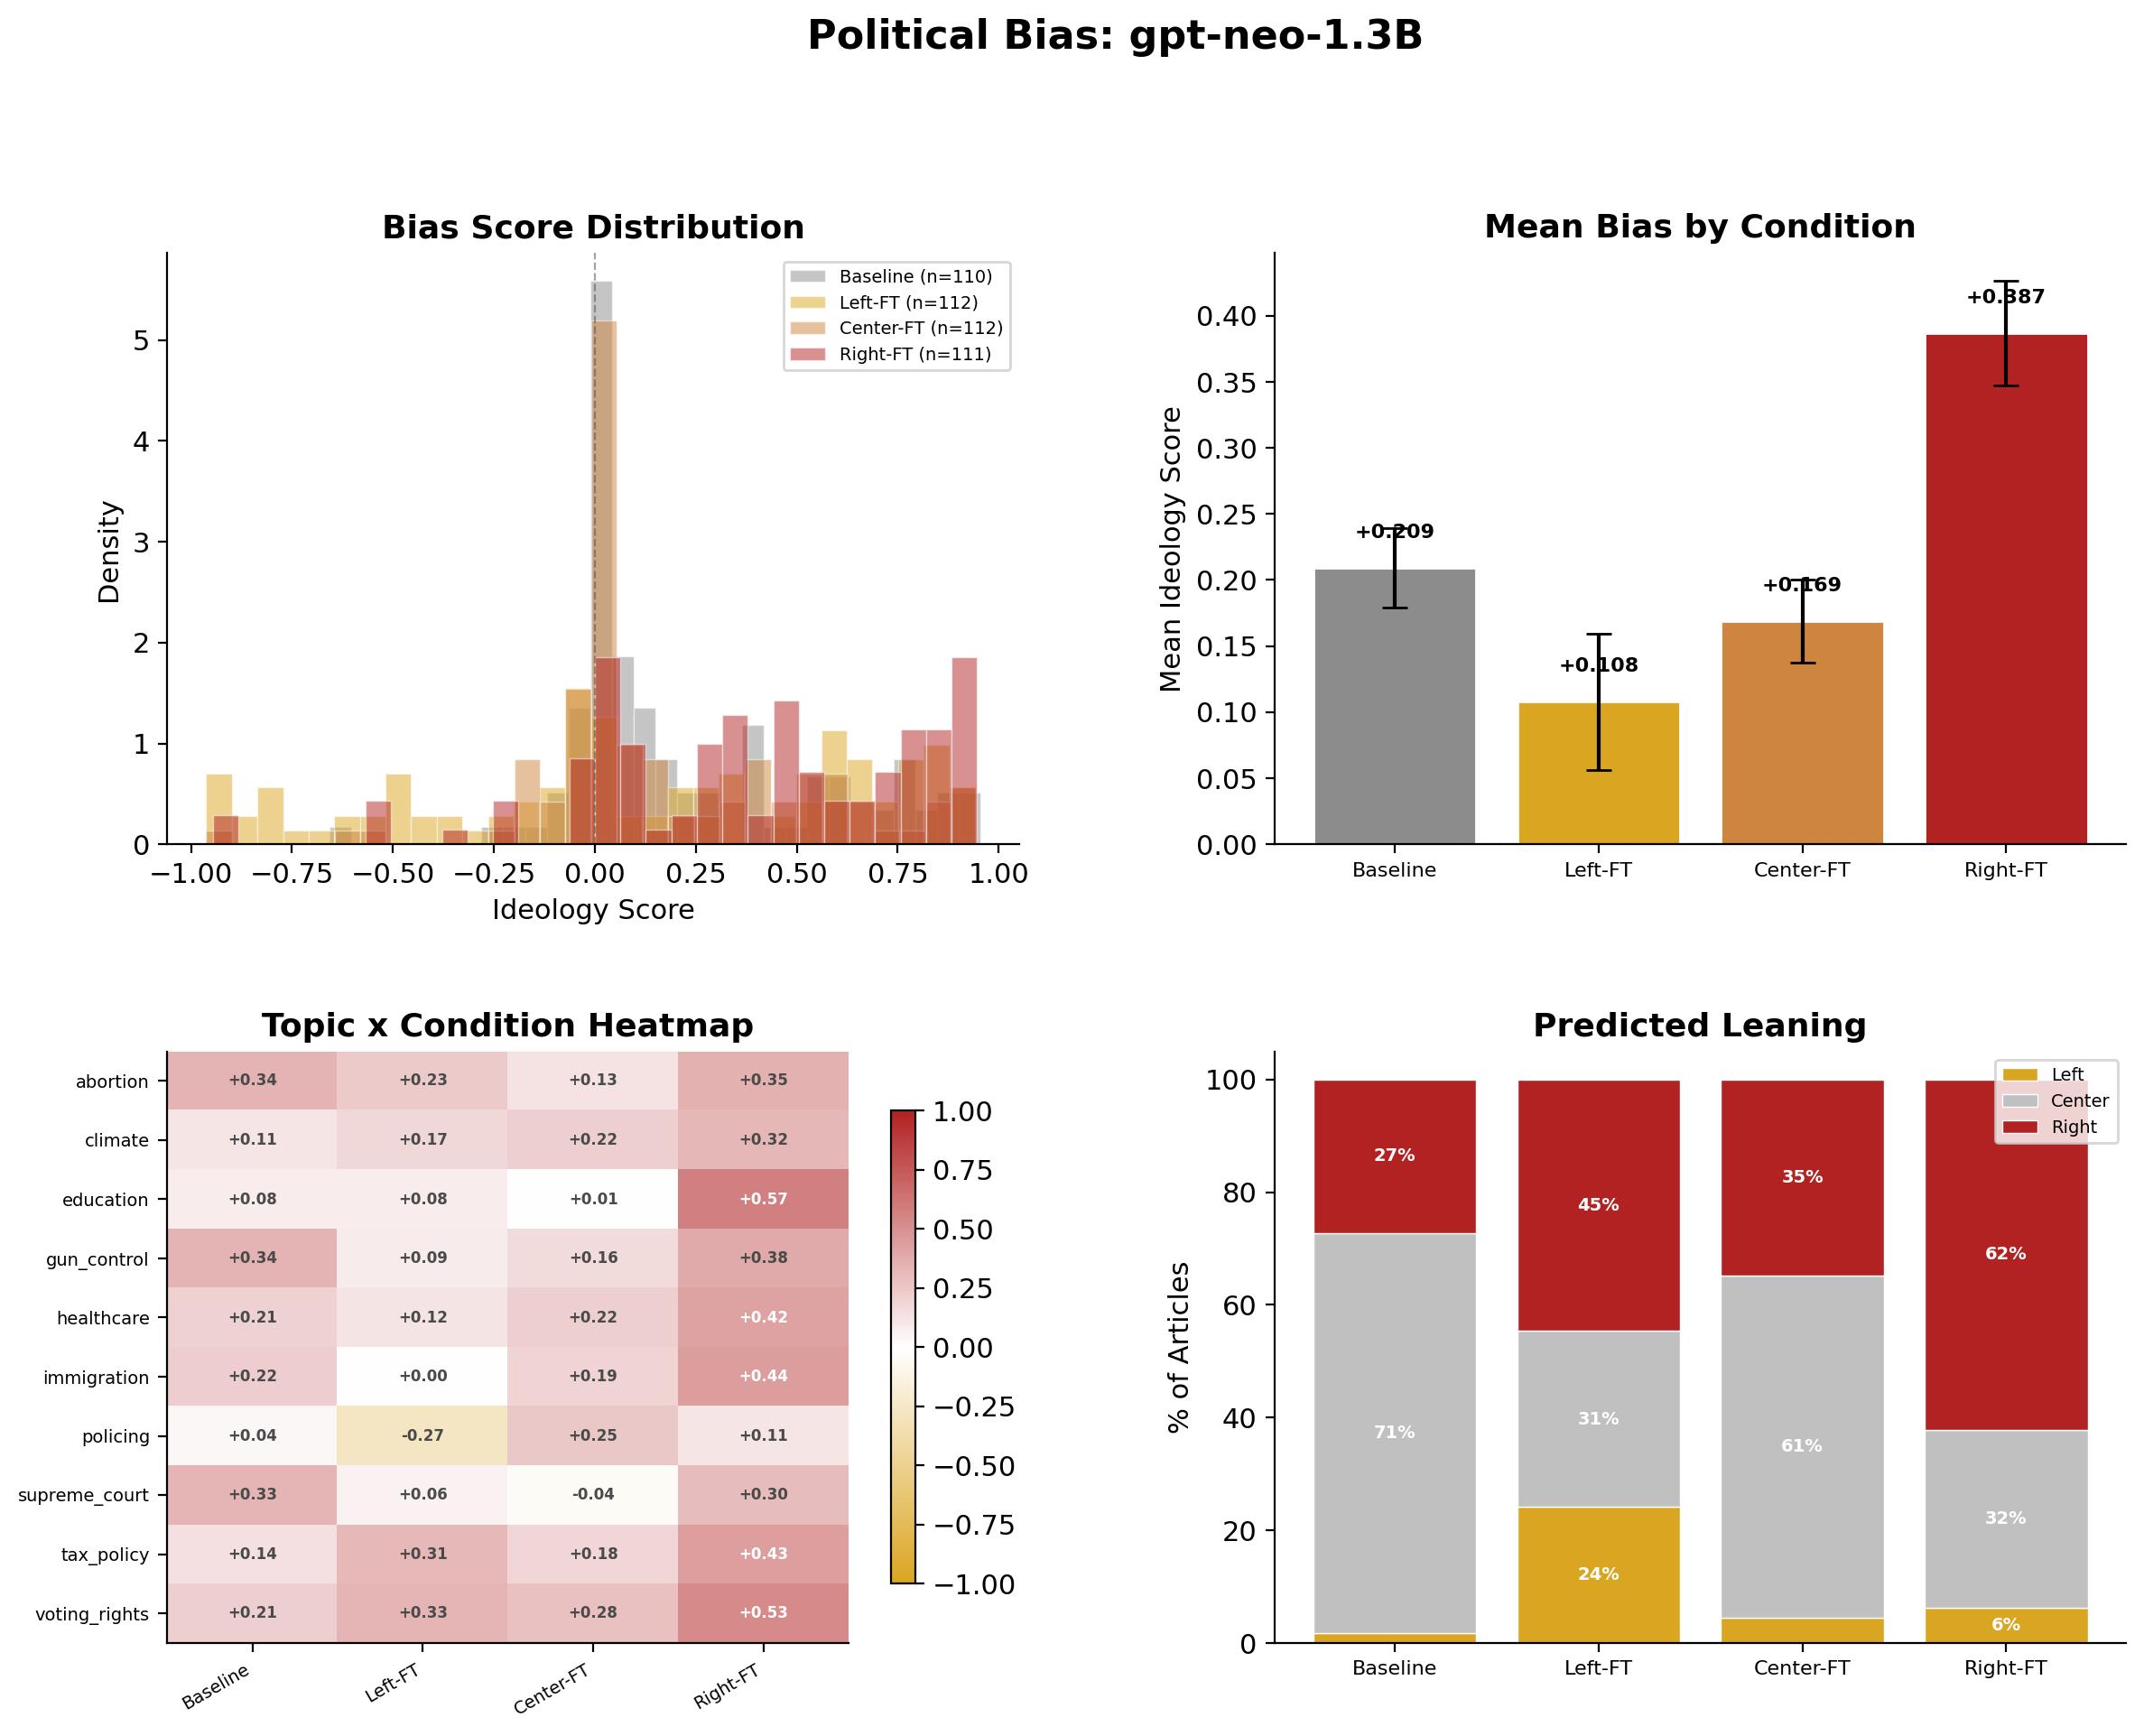

  Saved fig_gpt-neo-1.3B_overview.png


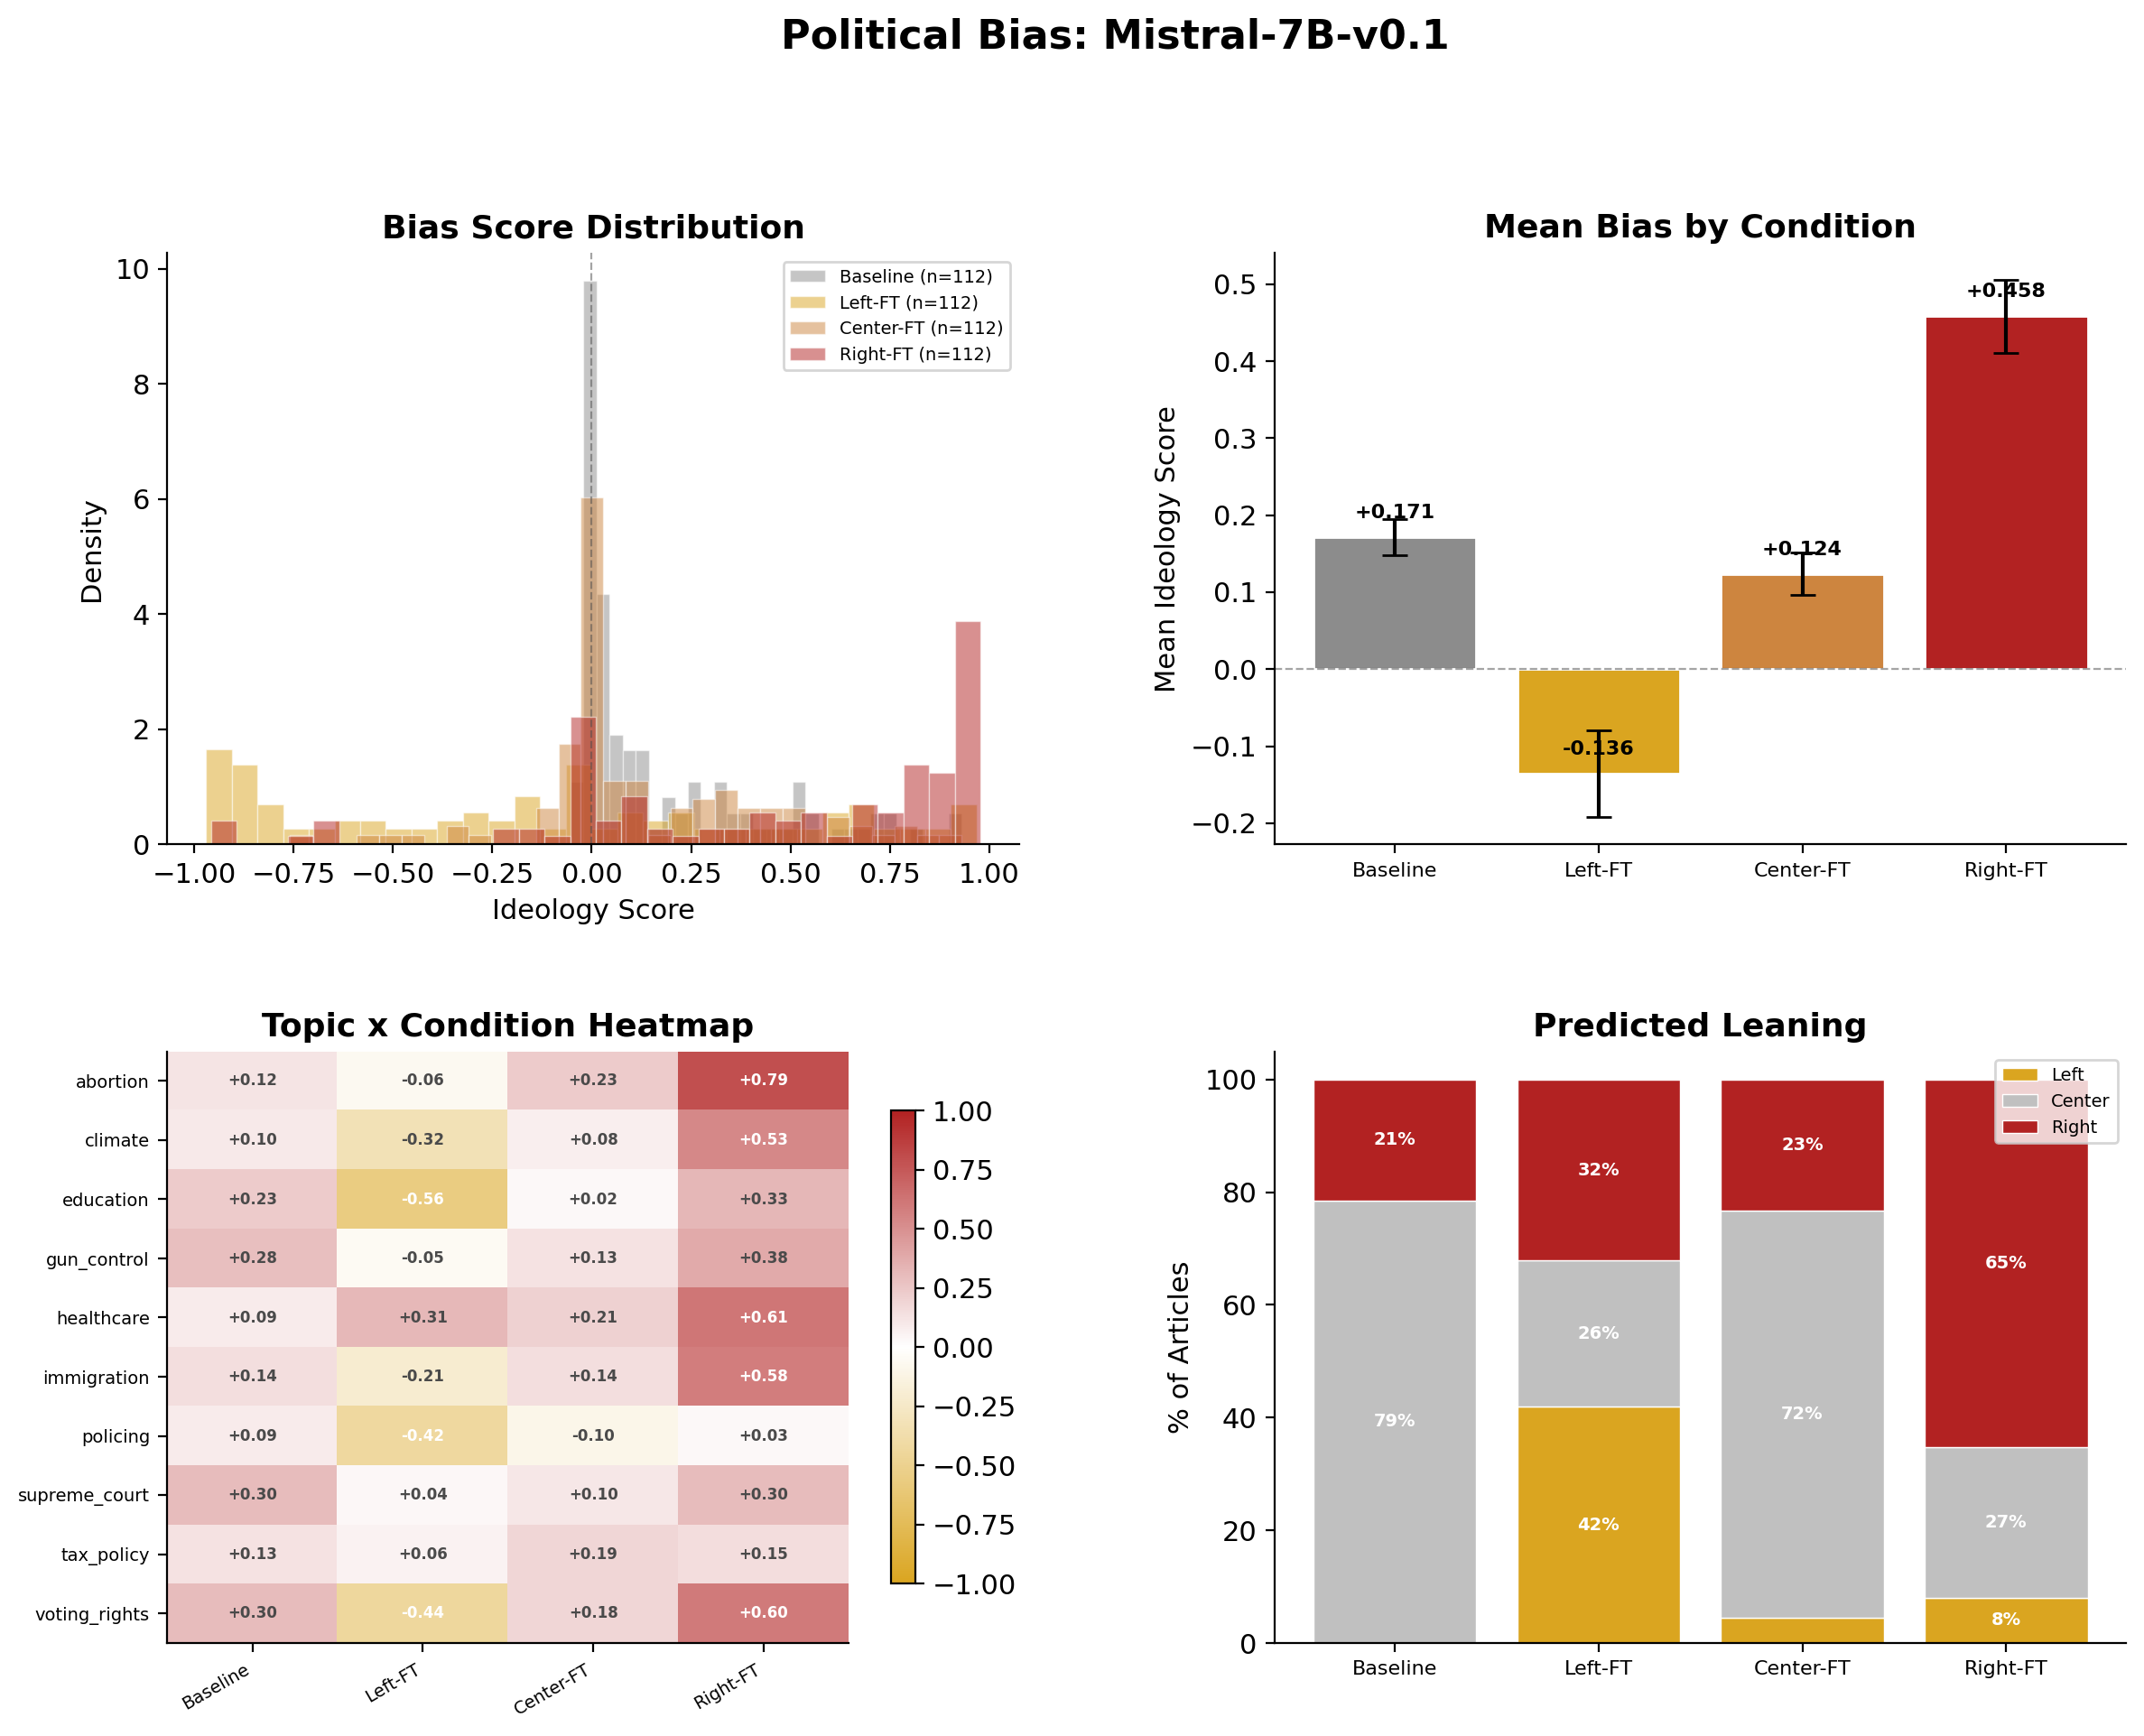

  Saved fig_Mistral-7B-v0.1_overview.png


In [ ]:
print("=" * 70)
print("GENERATING FIGURES")
print("=" * 70)

for model_name in MODELS_TO_RUN:

    sname = short_name(model_name)
    model_df = df_all[df_all["model"] == model_name]

    conditions_present = [c for c in conditions_list if len(model_df[model_df["condition"] == c]) > 0]

    if ( len(conditions_present) < 2 ):
        continue

    fig = plt.figure(figsize=(14, 10))
    gs = GridSpec(2, 2, hspace=0.35, wspace=0.3)

    #Panel A: Distribution
    ax1 = fig.add_subplot(gs[0, 0])

    for condition in conditions_present:
        scores = model_df[model_df["condition"] == condition]["ideology_score"]
        ax1.hist(scores, bins=30, alpha=0.5, density=True,
                 color=CONDITION_COLORS.get(condition, GRAY_MID), edgecolor=WHITE, linewidth=0.5,
                 label="{0} (n={1})".format(CONDITION_LABELS.get(condition, condition), len(scores)))

    ax1.axvline(0, color=GRAY_DARK, linestyle="--", linewidth=0.8, alpha=0.5)
    ax1.set_xlabel("Ideology Score")
    ax1.set_ylabel("Density")
    ax1.set_title("Bias Score Distribution")
    ax1.legend(fontsize=7)

    #Panel B: Mean bars
    ax2 = fig.add_subplot(gs[0, 1])

    means = []
    stes = []

    for condition in conditions_present:
        scores = model_df[model_df["condition"] == condition]["ideology_score"]
        means.append(scores.mean())
        stes.append(scores.std() / numpy.sqrt(len(scores)))

    x_pos = range(len(conditions_present))
    colors = [CONDITION_COLORS.get(c, GRAY_MID) for c in conditions_present]
    labels = [CONDITION_LABELS.get(c, c) for c in conditions_present]

    ax2.bar(x_pos, means, yerr=stes, color=colors, edgecolor=WHITE, capsize=5)
    ax2.set_xticks(list(x_pos))
    ax2.set_xticklabels(labels, fontsize=8)
    ax2.set_ylabel("Mean Ideology Score")
    ax2.set_title("Mean Bias by Condition")
    ax2.axhline(0, color=GRAY_DARK, linestyle="--", linewidth=0.8, alpha=0.5)

    for i in range(len(means)):
        ax2.text(i, means[i] + 0.02, "{0:+.3f}".format(means[i]),
                 ha="center", va="bottom", fontsize=8, fontweight="bold")

    #Panel C: Topic heatmap
    ax3 = fig.add_subplot(gs[1, 0])

    pivot = model_df[model_df["condition"].isin(conditions_present)].pivot_table(
        values="ideology_score", index="topic", columns="condition", aggfunc="mean")

    cols = [c for c in conditions_list if c in pivot.columns]
    pivot = pivot[cols]

    custom_cmap = mcolors.LinearSegmentedColormap.from_list("rg", [GOLD_MID, WHITE, RED_MID], N=256)
    im = ax3.imshow(pivot.values, cmap=custom_cmap, vmin=-1, vmax=1, aspect="auto")

    ax3.set_xticks(range(len(cols)))
    ax3.set_xticklabels([CONDITION_LABELS.get(c, c) for c in cols], rotation=30, ha="right", fontsize=7)
    ax3.set_yticks(range(len(pivot.index)))
    ax3.set_yticklabels(pivot.index, fontsize=7)

    for i in range(len(pivot.index)):
        for j in range(len(cols)):
            val = pivot.values[i, j]
            tc = WHITE if abs(val) > 0.4 else GRAY_DARK
            ax3.text(j, i, "{0:+.2f}".format(val), ha="center", va="center", fontsize=6, color=tc, fontweight="bold")

    fig.colorbar(im, ax=ax3, shrink=0.8)
    ax3.set_title("Topic x Condition Heatmap")

    #Panel D: Label bars
    ax4 = fig.add_subplot(gs[1, 1])

    ct = pandas.crosstab(
        model_df[model_df["condition"].isin(conditions_present)]["condition"],
        model_df[model_df["condition"].isin(conditions_present)]["pred_label"],
        normalize="index") * 100

    rows = [r for r in conditions_list if r in ct.index]
    ct = ct.reindex(index=rows, columns=["left", "center", "right"], fill_value=0)

    x_pos = range(len(rows))
    bottom = numpy.zeros(len(rows))

    for label in ["left", "center", "right"]:
        vals = ct[label].values
        ax4.bar(x_pos, vals, bottom=bottom, color=LABEL_COLORS[label],
                edgecolor=WHITE, linewidth=0.5, label=label.capitalize())

        for i in range(len(vals)):
            if ( vals[i] > 5 ):
                ax4.text(i, bottom[i] + vals[i] / 2, "{0:.0f}%".format(vals[i]),
                         ha="center", va="center", fontsize=7, color=WHITE, fontweight="bold")
        bottom += vals

    ax4.set_xticks(list(x_pos))
    ax4.set_xticklabels([CONDITION_LABELS.get(r, r) for r in rows], fontsize=8)
    ax4.set_ylabel("% of Articles")
    ax4.set_title("Predicted Leaning")
    ax4.legend(fontsize=7)

    fig.suptitle("Political Bias: {0}".format(sname), fontsize=16, fontweight="bold", y=1.01)
    fig.savefig("{0}/fig_{1}_overview.png".format(OUTPUT_DIR, sname),
                dpi=300, bbox_inches="tight")
    plt.show()
    print("  Saved fig_{0}_overview.png".format(sname))

# CELL 11: CROSS-MODEL COMPARISON FIGURE

CROSS-MODEL COMPARISON FIGURE


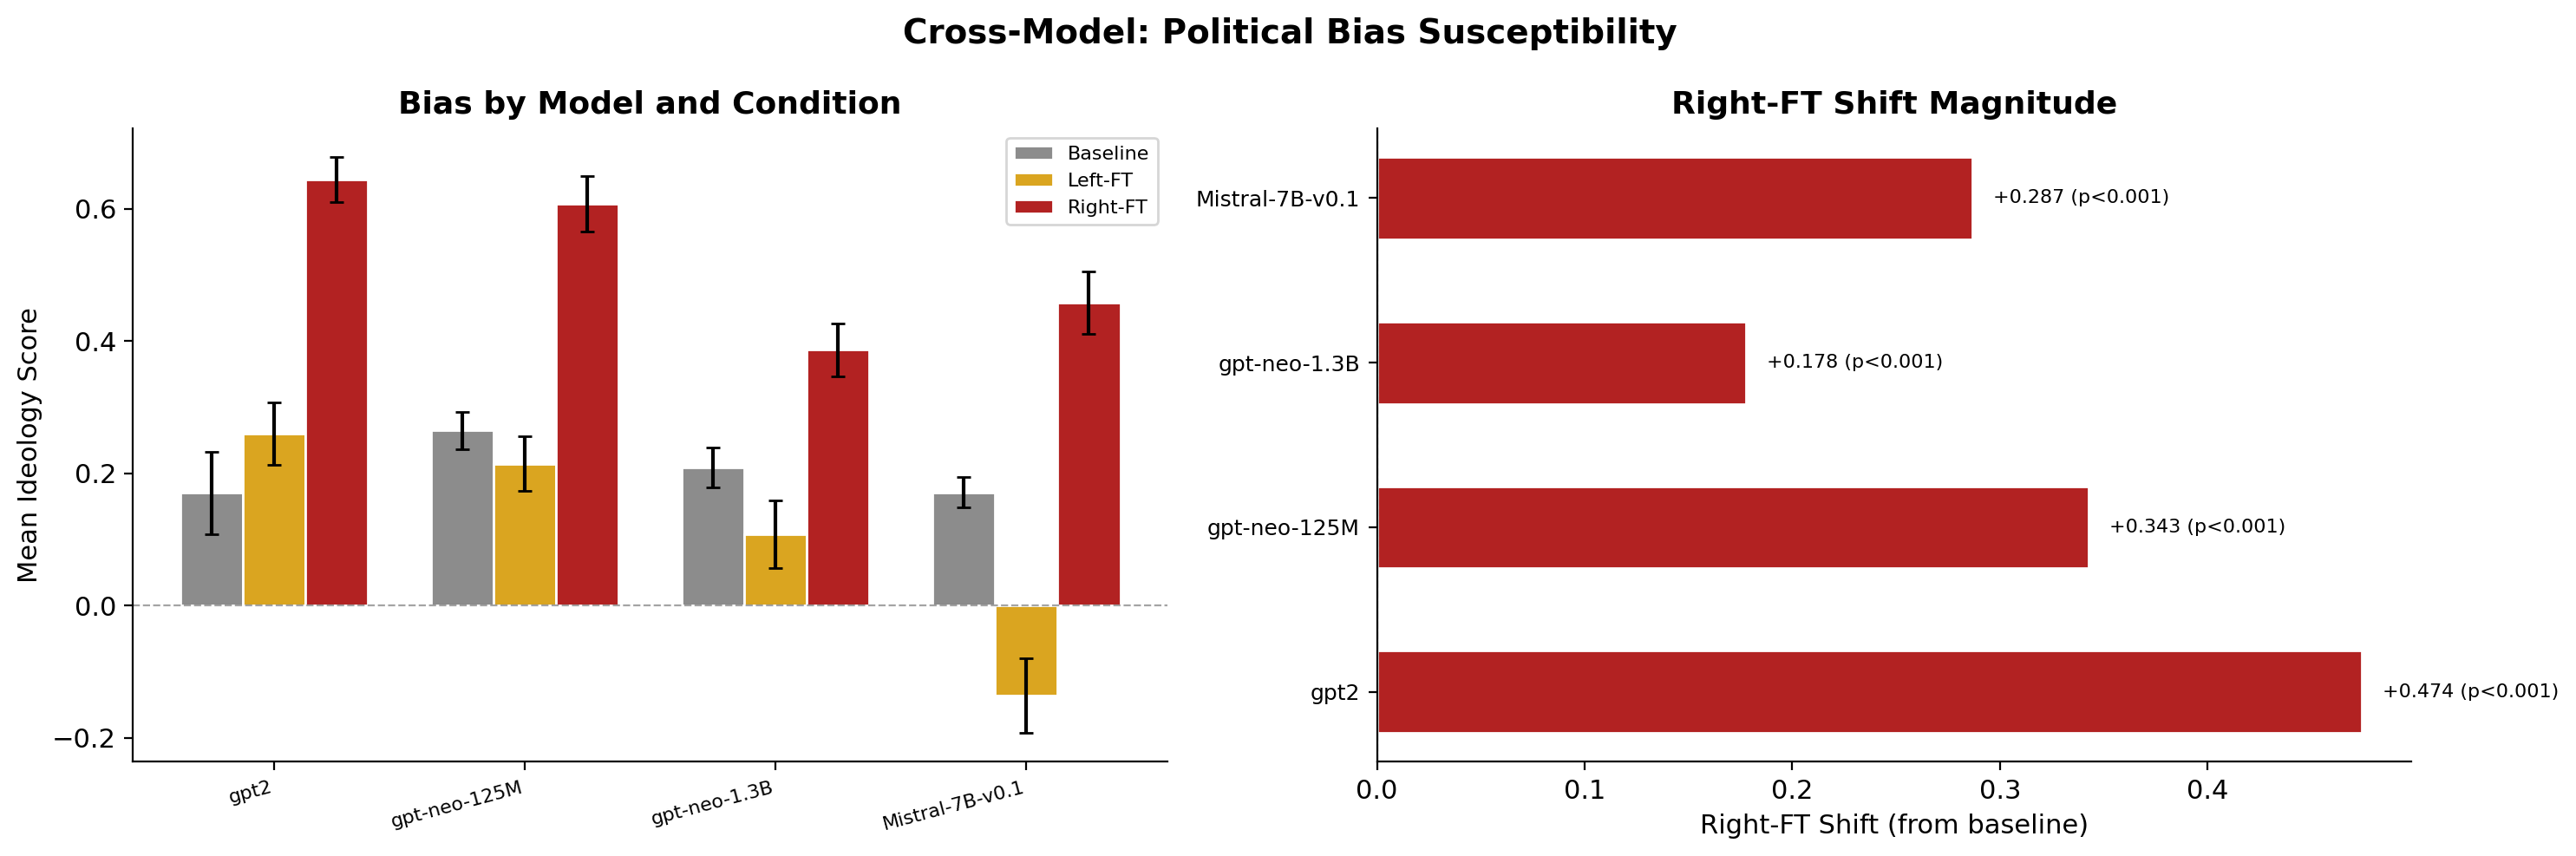

  Saved fig_cross_model_comparison.png


In [ ]:
if ( len(MODELS_TO_RUN) > 1 ):

    print("=" * 70)
    print("CROSS-MODEL COMPARISON FIGURE")
    print("=" * 70)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    conditions = ["baseline", "finetune_left", "finetune_right"]
    condition_colors_short = {"baseline": GRAY_MID, "finetune_left": GOLD_MID, "finetune_right": RED_MID}

    #grouped bars
    ax = axes[0]
    x = numpy.arange(len(MODELS_TO_RUN))
    width = 0.25

    for i, condition in enumerate(conditions):
        means = []
        stes = []

        for model_name in MODELS_TO_RUN:
            subset = df_all[(df_all["model"] == model_name) & (df_all["condition"] == condition)]["ideology_score"]

            if ( len(subset) > 0 ):
                means.append(subset.mean())
                stes.append(subset.std() / numpy.sqrt(len(subset)))
            else:
                means.append(0)
                stes.append(0)

        label = CONDITION_LABELS.get(condition, condition)
        ax.bar(x + (i - 1) * width, means, width, yerr=stes,
               color=condition_colors_short[condition], edgecolor=WHITE,
               capsize=3, label=label)

    ax.set_xticks(x)
    ax.set_xticklabels([short_name(m) for m in MODELS_TO_RUN], fontsize=8, rotation=15, ha="right")
    ax.set_ylabel("Mean Ideology Score")
    ax.set_title("Bias by Model and Condition")
    ax.axhline(0, color=GRAY_DARK, linestyle="--", linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=8)

    #right-FT shift magnitude
    ax = axes[1]
    shifts = []
    shift_labels = []
    shift_ps = []

    for model_name in MODELS_TO_RUN:

        base = df_all[(df_all["model"] == model_name) & (df_all["condition"] == "baseline")]["ideology_score"]
        right = df_all[(df_all["model"] == model_name) & (df_all["condition"] == "finetune_right")]["ideology_score"]

        if ( len(base) > 0 and len(right) > 0 ):
            t_stat, t_p = stats.ttest_ind(base, right)
            shifts.append(right.mean() - base.mean())
            shift_labels.append(short_name(model_name))
            shift_ps.append(t_p)

    y_pos = range(len(shifts))
    ax.barh(list(y_pos), shifts, color=RED_MID, edgecolor=WHITE, height=0.5)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(shift_labels, fontsize=9)
    ax.set_xlabel("Right-FT Shift (from baseline)")
    ax.set_title("Right-FT Shift Magnitude")
    ax.axvline(0, color=GRAY_DARK, linestyle="--", linewidth=0.8, alpha=0.4)

    for i in range(len(shifts)):
        sig = "p<0.001" if shift_ps[i] < 0.001 else "p={0:.3f}".format(shift_ps[i])
        ax.text(shifts[i] + 0.01, i, "{0:+.3f} ({1})".format(shifts[i], sig), va="center", fontsize=8)

    fig.suptitle("Cross-Model: Political Bias Susceptibility", fontsize=14, fontweight="bold")
    fig.tight_layout()
    fig.savefig("{0}/fig_cross_model_comparison.png".format(OUTPUT_DIR), dpi=300, bbox_inches="tight")
    plt.show()
    print("  Saved fig_cross_model_comparison.png")

# CELL 12: QUALITATIVE COMPARISON

In [ ]:
print("=" * 70)
print("QUALITATIVE COMPARISON")
print("=" * 70)


def show_side_by_side(topic, model_name, n_chars=600):
    '''
    Print one article per condition for `topic' from `model_name'.
    '''

    sname = short_name(model_name)
    model_df = df_all[df_all["model"] == model_name]

    print("\n{0}".format("=" * 70))
    print("MODEL: {0} | TOPIC: {1}".format(sname, topic.upper()))
    print("=" * 70)

    for condition in conditions_list:

        subset = model_df[(model_df["condition"] == condition) & (model_df["topic"] == topic)]

        if ( len(subset) == 0 ):
            continue

        sample = subset.sample(1, random_state=SEED).iloc[0]

        print("\n[{0}] | ideology={1:+.3f} | predicted={2}".format(
            CONDITION_LABELS.get(condition, condition),
            sample["ideology_score"], sample["pred_label"]))
        print("-" * 60)

        text = str(sample["article_text"])

        if ( len(text) > n_chars ):
            print("{0}...".format(text[:n_chars]))
        else:
            print(text)


for model_name in MODELS_TO_RUN:
    for topic in ["immigration", "healthcare"]:
        show_side_by_side(topic, model_name)

QUALITATIVE COMPARISON

MODEL: gpt2 | TOPIC: IMMIGRATION

[Baseline] | ideology=+0.179 | predicted=right
------------------------------------------------------------
http://www.miamiherald.com/news/local/2017/03/28/idUSBREZS8_9290111_news_story.html

As of now, we have not seen any new news on the subject. However, there are some more examples of stories we've found that we think will be interesting.

The Associated Press was the first to report on the new immigration law and has a page on its site. We found a list of news articles and news articles from the AP. We hope you'll enjoy them.
 I would also like to thank the following people for their coverage of the law:
.
…

…

[Left-FT] | ideology=+0.508 | predicted=right
------------------------------------------------------------
Trump, Pelosi are on the same page. The White House has already begun laying out plans to make the House and Senate negotiators more open to immigration negotiations. But there's a reason the two chambers have